# NAP Rule Evolution Viewer

Use this notebook to view how one class-specific NAP changes across training checkpoints.

Each image is one `model + class + alpha + checkpoint`.

Color legend:

- `ALWAYS_ON`: light purple
- `ALWAYS_OFF`: light green
- no rule: white


In [6]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

CHECKPOINT_ORDER = ["epoch_000", "epoch_025", "epoch_050", "epoch_075", "epoch_100"]

def find_image_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "update_overview" / "nap_rule_images",
        Path.cwd().parent / "nap_rule_images",
    ]
    for candidate in candidates:
        if (candidate / "image_index.csv").is_file():
            return candidate.resolve()
    raise FileNotFoundError("Could not find image_index.csv. Open this notebook from the nap_rule_images directory or repo root.")

IMAGE_DIR = find_image_dir()
INDEX_PATH = IMAGE_DIR / "image_index.csv"

with INDEX_PATH.open(newline="", encoding="utf-8") as f:
    IMAGE_ROWS = list(csv.DictReader(f))

MODELS = sorted({row["model"] for row in IMAGE_ROWS})
ALPHAS = sorted({row["alpha"] for row in IMAGE_ROWS}, key=float)
CLASSES = list(range(10))

print(f"Image directory: {IMAGE_DIR}")
print(f"Images indexed: {len(IMAGE_ROWS)}")
print("Models:", MODELS)
print("Alphas:", ALPHAS)


Image directory: /Users/heliu/Desktop/ENS/Remote-cluster/vnncomp_net/update_overview/nap_rule_images
Images indexed: 1250
Models: ['seed0_4x250', 'seed0_7x100', 'seed0_7x250', 'seed123_7x250', 'seed42_7x250']
Alphas: ['0.90', '0.93', '0.95', '0.97', '0.99']


## Manual Input

Edit the following variables and run the cell to display the selected sequence.

In [10]:
# Edit these values.
MODEL = "seed0_4x250"
CLASS_ID = 8
ALPHA = "0.99"
LAYOUT = "vertical"  # "vertical" or "horizontal"


### seed0_4x250 | class 8 | alpha=0.99

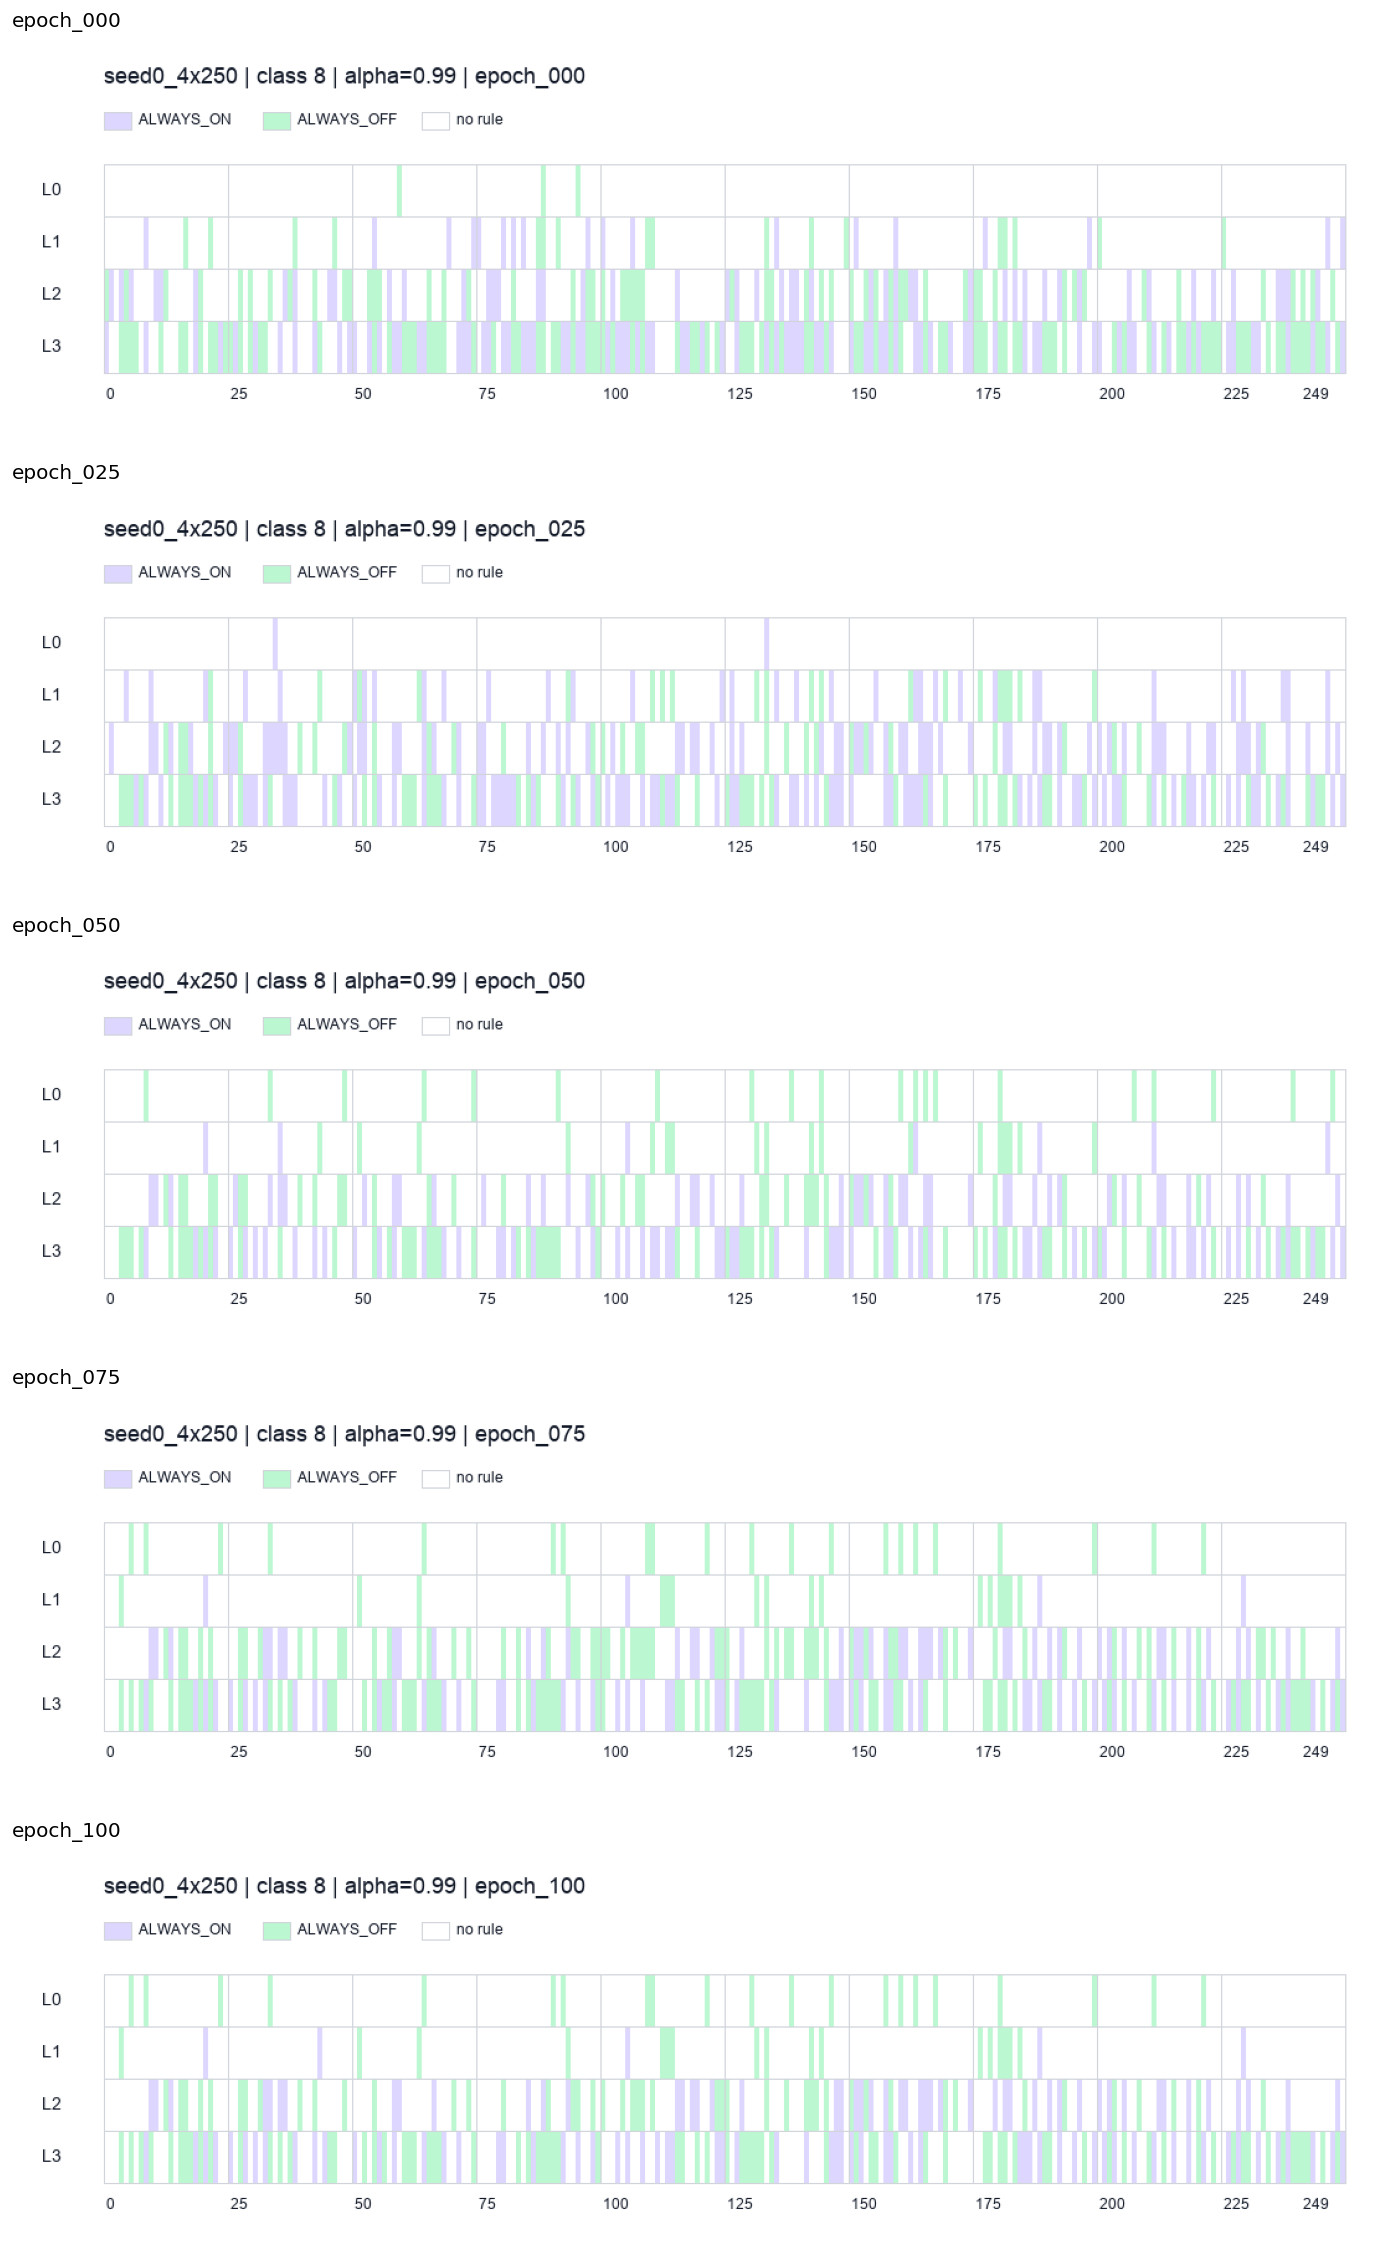

In [11]:
def normalize_alpha(alpha):
    return f"{float(alpha):.2f}"

def image_path_for(model, class_id, alpha, checkpoint):
    alpha = normalize_alpha(alpha)
    matches = [
        row for row in IMAGE_ROWS
        if row["model"] == model
        and int(row["class_id"]) == int(class_id)
        and normalize_alpha(row["alpha"]) == alpha
        and row["checkpoint"] == checkpoint
    ]
    if not matches:
        return None
    path = Path(matches[0]["image_path"])
    if path.is_file():
        return path
    fallback = IMAGE_DIR / path.name
    return fallback if fallback.is_file() else None

def show_evolution(model=MODEL, class_id=CLASS_ID, alpha=ALPHA, layout=LAYOUT, dpi=120):
    paths = []
    missing = []
    for checkpoint in CHECKPOINT_ORDER:
        path = image_path_for(model, class_id, alpha, checkpoint)
        if path is None:
            missing.append(checkpoint)
        else:
            paths.append((checkpoint, path))

    if missing:
        display(Markdown(f"**Missing checkpoints:** {', '.join(missing)}"))
    if not paths:
        display(Markdown("No images found for this selection."))
        return

    display(Markdown(f"### {model} | class {class_id} | alpha={normalize_alpha(alpha)}"))

    images = [(checkpoint, Image.open(path).convert("RGB")) for checkpoint, path in paths]

    if layout == "horizontal":
        fig, axes = plt.subplots(1, len(images), figsize=(5.0 * len(images), 4.0), dpi=dpi)
        if len(images) == 1:
            axes = [axes]
        for ax, (checkpoint, image) in zip(axes, images):
            ax.imshow(image)
            ax.set_title(checkpoint)
            ax.axis("off")
    else:
        fig, axes = plt.subplots(len(images), 1, figsize=(12.0, 3.8 * len(images)), dpi=dpi)
        if len(images) == 1:
            axes = [axes]
        for ax, (checkpoint, image) in zip(axes, images):
            ax.imshow(image)
            ax.set_title(checkpoint, loc="left")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_evolution(MODEL, CLASS_ID, ALPHA, LAYOUT)


## Optional Interactive Selector

Run the next cell if `ipywidgets` is available in your Jupyter environment.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    model_widget = widgets.Dropdown(options=MODELS, value=MODEL if MODEL in MODELS else MODELS[0], description="Model")
    class_widget = widgets.Dropdown(options=CLASSES, value=CLASS_ID, description="Class")
    alpha_widget = widgets.Dropdown(options=ALPHAS, value=normalize_alpha(ALPHA), description="Alpha")
    layout_widget = widgets.Dropdown(options=["vertical", "horizontal"], value=LAYOUT, description="Layout")
    output = widgets.Output()

    def refresh(*_):
        with output:
            clear_output(wait=True)
            show_evolution(
                model_widget.value,
                class_widget.value,
                alpha_widget.value,
                layout_widget.value,
            )

    for widget in [model_widget, class_widget, alpha_widget, layout_widget]:
        widget.observe(refresh, names="value")

    display(widgets.HBox([model_widget, class_widget, alpha_widget, layout_widget]))
    display(output)
    refresh()
except Exception as exc:
    print("Interactive widgets are unavailable. Use the manual input cells above.")
    print(type(exc).__name__, exc)


Output()